# Import Library

In [1]:
import numpy as np
import matplotlib as plt
import seaborn as sns
import requests
import pandas as pd
from bs4 import BeautifulSoup
import openpyxl

# Scrapping Website CoinMarketCap

In [2]:
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import requests
import pandas as pd
from bs4 import BeautifulSoup


def scrape():
    url = 'https://coinmarketcap.com/gainers-losers/'
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) ...'
    }
    try:
        response = requests.get(url, headers=headers)
    except Exception as e:
        print(f"Koneksi gagal: {e}")
        return [], []

    if response.status_code != 200:
        print(f'Error: {response.status_code}')
        return [], []

    soup = BeautifulSoup(response.text, 'html.parser')
    tables = soup.findAll('table', class_='cmc-table')

    if len(tables) < 2:
        print("Tabel tidak ditemukan (kemungkinan konten di-render oleh JS).")
        return [], []

    def parse_table(target_table):
        data = []
        rows = target_table.findAll('tr')[1:]
        for row in rows:
            cols = row.findAll('td')
            if len(cols) >= 5:  # ✅ minimal 5 kolom
                data.append({
                    "Name": cols[1].text.strip(),
                    "Price": cols[2].text.strip(),
                    "24h Change": cols[3].text.strip(),
                    "Volume(24h)": cols[4].text.strip()
                })
        return data

    return parse_table(tables[0]), parse_table(tables[1])

gainers, losers = scrape()

if gainers or losers:
    df_gainers = pd.DataFrame(gainers)
    df_gainers.to_excel("gainers.xlsx", index=False)  # ✅ index=False

    df_losers = pd.DataFrame(losers)
    df_losers.to_excel("losers.xlsx", index=False)

C:\Users\Asus\AppData\Local\Temp\ipykernel_18148\2900036570.py:25: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  tables = soup.findAll('table', class_='cmc-table')
C:\Users\Asus\AppData\Local\Temp\ipykernel_18148\2900036570.py:33: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  rows = target_table.findAll('tr')[1:]
C:\Users\Asus\AppData\Local\Temp\ipykernel_18148\2900036570.py:35: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  cols = row.findAll('td')


# DataFrame Gainners Coin

In [3]:
gainners = pd.read_excel("gainers.xlsx")
dataframe_gainners = pd.DataFrame(gainners)
dataframe_gainners.head(10)

,Name,Price,24h Change,Volume(24h)
0,RaveDAO99RAVE,$1.41,136.28%,"$635,200,958"
1,MemeCore18M,$4.23,17.90%,"$23,067,404"
2,JUST68JST,$0.08079,8.83%,"$44,325,127"
3,Monero14XMR,$372.73,5.26%,"$135,937,740"
4,Dash88DASH,$35.94,5.03%,"$104,540,161"
5,Stellar16XLM,$0.1786,4.52%,"$178,822,646"
6,LayerZero79ZRO,$1.61,4.34%,"$82,537,989"
7,Aave46AAVE,$91.80,3.26%,"$577,188,271"
8,Toncoin29TON,$1.37,3.17%,"$193,037,824"
9,Midnight71NIGHT,$0.0369,3.15%,"$28,358,005"


# DataFrame Lossers Coin

In [5]:
loserss = pd.read_excel("losers.xlsx")
dataframe_losers = pd.DataFrame(loserss)
dataframe_losers.head(10)

,Name,Price,24h Change,Volume(24h)
0,DeXe53DEXE,$12.56,10.69%,"$36,036,307"
1,Hyperliquid10HYPE,$39.83,3.36%,"$350,687,873"
2,Pi42PI,$0.1678,3.21%,"$24,045,625"
3,Ethena56ENA,$0.1111,3.09%,"$101,641,819"
4,ether.fi97ETHFI,$0.4479,3.00%,"$23,498,324"
5,Arbitrum65ARB,$0.1253,2.85%,"$73,778,239"
6,Quant61QNT,$72.79,2.75%,"$8,741,400"
7,Canton17CC,$0.152,2.48%,"$28,301,899"
8,Tether Gold32XAUt,"$4,697.39",1.92%,"$180,867,525"
9,PAX Gold35PAXG,"$4,699.77",1.92%,"$213,111,981"


# Check Missing Value Gainners

In [6]:
df_gainers.isnull().sum()

Name           0
Price          0
24h Change     0
Volume(24h)    0
dtype: int64

# Check Missing Value Lossers

In [7]:
df_losers.isnull().sum()

Name           0
Price          0
24h Change     0
Volume(24h)    0
dtype: int64

# Data Cleaning Gainners & Lossers

In [8]:
for df in [df_gainers, df_losers]:
    df['Price'] = df['Price'].str.replace('$', '', regex=False).str.replace(',', '').astype(float)
    df['24h Change'] = df['24h Change'].str.replace('%', '', regex=False).astype(float)
    df['Volume(24h)'] = df['Volume(24h)'].str.replace('$', '', regex=False).str.replace(',', '').astype(float)

df_gainers.head()

,Name,Price,24h Change,Volume(24h)
0,RaveDAO99RAVE,1.41000,136.28,635200958.0
1,MemeCore18M,4.23000,17.90,23067404.0
2,JUST68JST,0.08079,8.83,44325127.0
3,Monero14XMR,372.73000,5.26,135937740.0
4,Dash88DASH,35.94000,5.03,104540161.0


# Check Outlier Gainners

In [9]:
Q1 = df_gainers['Price'].quantile(0.25)
Q3 = df_gainers['Price'].quantile(0.75)
IQR = Q3 - Q1  

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_iqr = df_gainers[
    (df_gainers['Price'] < lower) | (df_gainers['Price'] > upper)
]

print('Jumlah outlier dari gainers: ', len(outlier_iqr))

Jumlah outlier dari gainers:  5


# Check Outlier Lossers

In [10]:
Q1 = df_losers['Price'].quantile(0.25)
Q3 = df_losers['Price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

qutlier_iqr = df_losers[
    (df_losers['Price'] < lower) | (df_losers['Price'] > upper)
]

print('Jumlah outlier dari losers: ', len(qutlier_iqr))

Jumlah outlier dari losers:  7


# Handling Outlier Gainners

In [11]:
data_iqr_clean_gainners = df_gainers[
    (df_gainers['Price'] >= lower) & (df_gainers['Price'] <= upper)
]

print("Jumlah data yang bersih: ", len(data_iqr_clean_gainners))

Jumlah data yang bersih:  22


# EDA Gainners

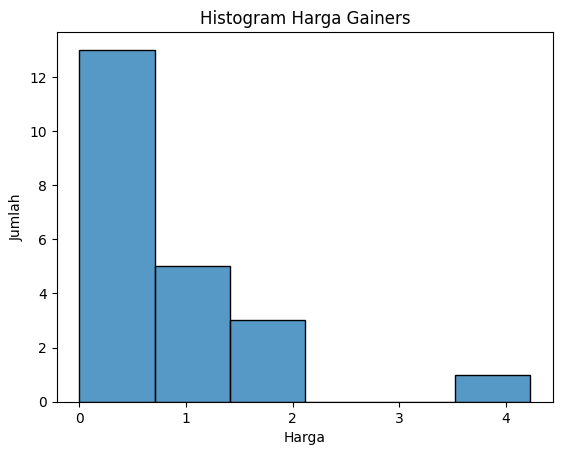

In [12]:
import matplotlib.pyplot as plt
sns.histplot(data=data_iqr_clean_gainners[data_iqr_clean_gainners['Price'] <  20000], x='Price')
plt.xlabel('Harga')
plt.ylabel('Jumlah')
plt.title('Histogram Harga Gainers')
plt.show()

# Handling Outlier Lossers

In [13]:
data_iqr_clean_lossers = df_losers[
    (df_losers['Price'] >= lower) & (df_losers['Price'] <= upper)
]

print("Jumlah data yang bersih: ", len(data_iqr_clean_lossers))

Jumlah data yang bersih:  23


# EDA lossers

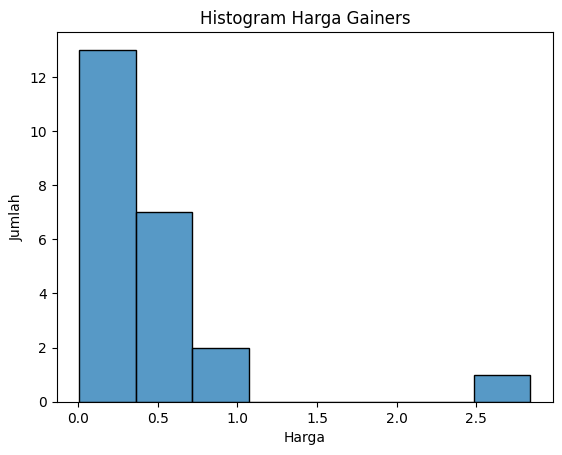

In [14]:
import matplotlib.pyplot as plt
sns.histplot(data=data_iqr_clean_lossers[data_iqr_clean_lossers['Price'] <  20000], x='Price')
plt.xlabel('Harga')
plt.ylabel('Jumlah')
plt.title('Histogram Harga Gainers')
plt.show()

# EDA Pie Chart (Perubahan Koin Gainners dalam 24 jam terakhir)

d:\KULIAH\semester 2\Praktikum pemrosdas\Scrapping Web Crypto\.env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24065 (\N{CJK UNIFIED IDEOGRAPH-5E01}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\KULIAH\semester 2\Praktikum pemrosdas\Scrapping Web Crypto\.env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23433 (\N{CJK UNIFIED IDEOGRAPH-5B89}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\KULIAH\semester 2\Praktikum pemrosdas\Scrapping Web Crypto\.env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\KULIAH\semester 2\Praktikum pemrosdas\Scrapping Web Crypto\.env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

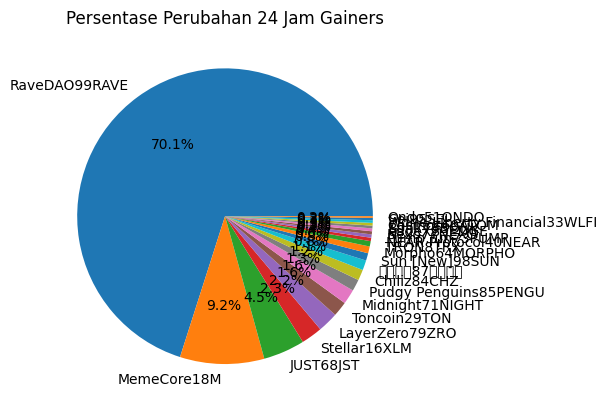

In [15]:
plt.Figure(figsize=(10, 6))
plt.pie(data_iqr_clean_gainners['24h Change'], labels=data_iqr_clean_gainners['Name'], autopct='%1.1f%%')
plt.title('Persentase Perubahan 24 Jam Gainers')
plt.show()

# EDA Pie Chart (Perubahan Koin Lossers dalam 24 jam terakhir)

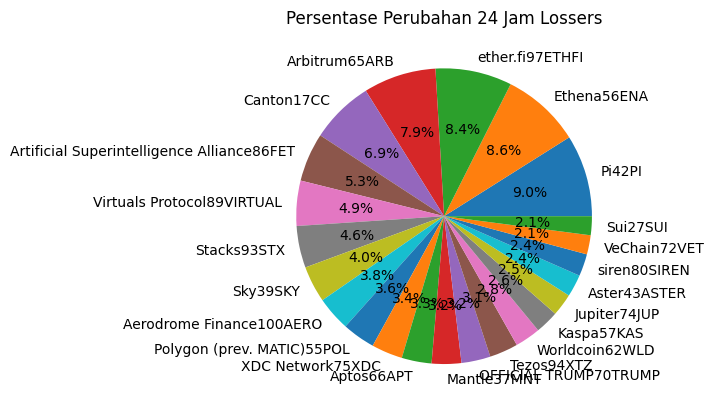

In [16]:
plt.Figure(figsize=(10, 6))
plt.pie(data_iqr_clean_lossers['24h Change'], labels=data_iqr_clean_lossers['Name'], autopct='%1.1f%%')
plt.title('Persentase Perubahan 24 Jam Lossers')
plt.show()

# Comparation Gonners and Lossers 

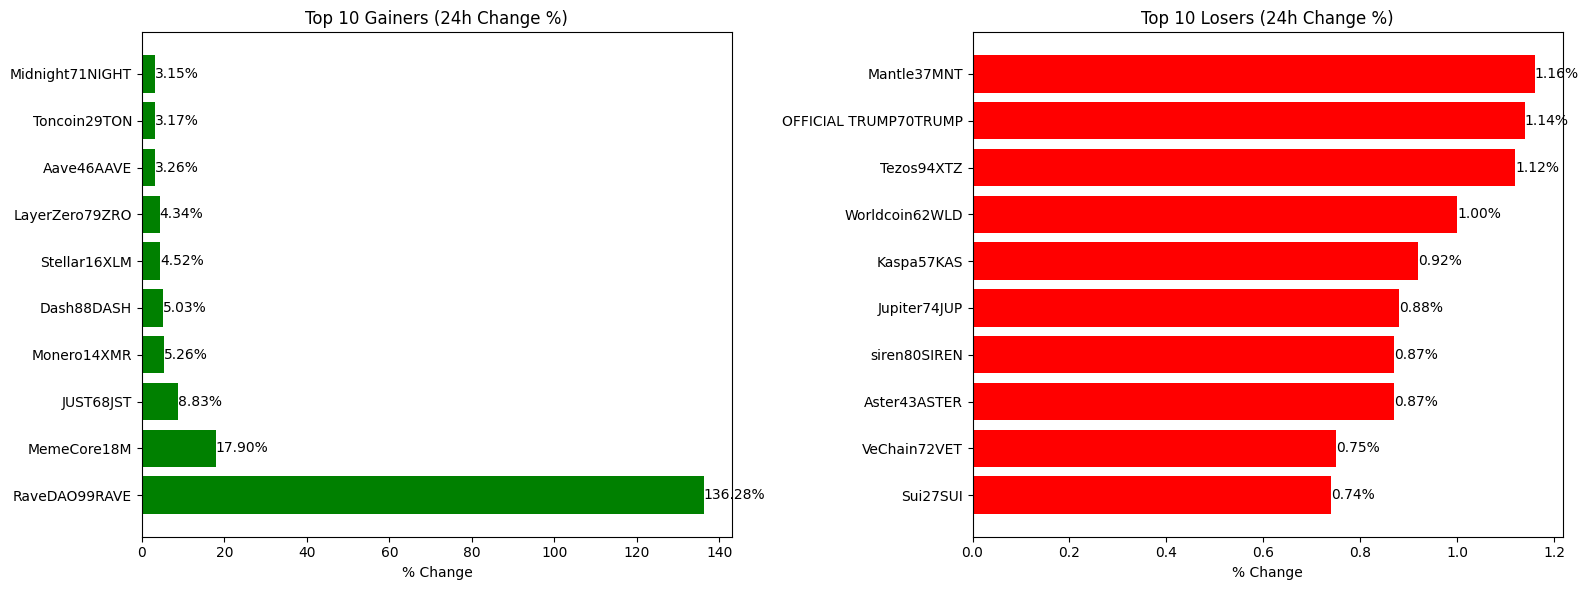

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_gainers = df_gainers.nlargest(10, '24h Change')
axes[0].barh(top_gainers['Name'], top_gainers['24h Change'], color='green')
axes[0].set_title('Top 10 Gainers (24h Change %)')
axes[0].set_xlabel('% Change')

top_losers = df_losers.nsmallest(10, '24h Change')
axes[1].barh(top_losers['Name'], top_losers['24h Change'], color='red')
axes[1].set_title('Top 10 Losers (24h Change %)')
axes[1].set_xlabel('% Change')

for i in top_gainers,top_losers:
     for index, value in enumerate(i['24h Change']):
        axes[0 if i is top_gainers else 1].text(value, index, f'{value:.2f}%', va='center')
        

plt.tight_layout()
plt.show()

# EDA Top 5 Gainners & Lossers by Volume

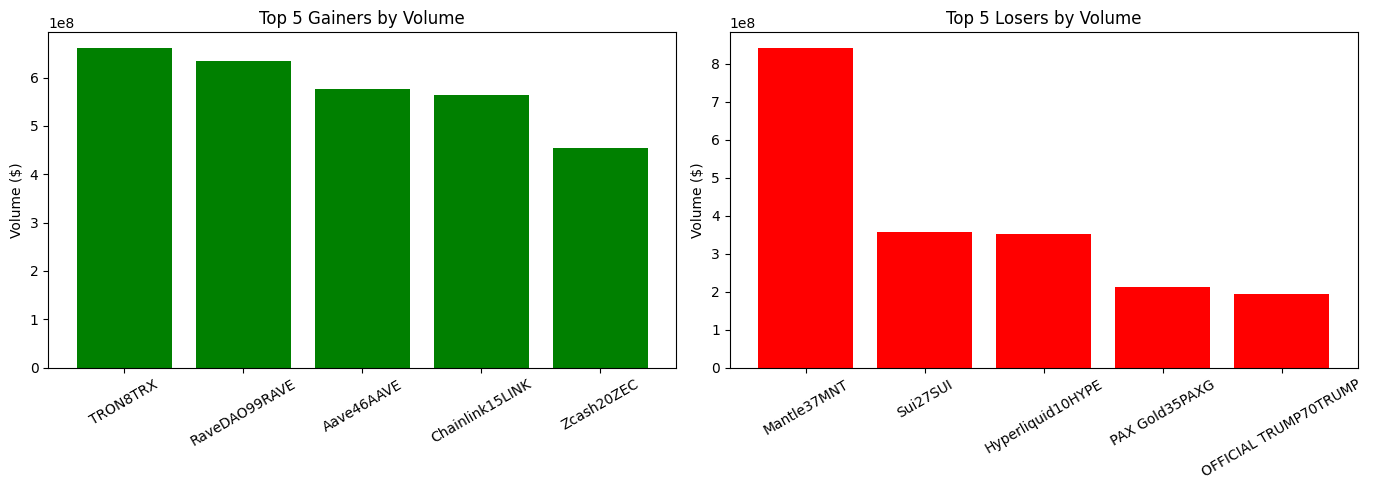

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title, color in zip(
    axes,
    [df_gainers, df_losers],
    ['Top 5 Gainers by Volume', 'Top 5 Losers by Volume'],
    ['green', 'red']
):
    top = df.nlargest(5, 'Volume(24h)')
    ax.bar(top['Name'], top['Volume(24h)'], color=color)
    ax.set_title(title)
    ax.set_ylabel('Volume ($)')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()